In [ ]:
# Step 1: Problem Definition and Dataset Selection

# Using dataset: Consumer Behavior and Shopping Habits Dataset (from Kaggle)

# Problem: Predict whether a customer subscribes based on their 
# demographics and purchase behavior.

# Task: Supervised Learning – Classification (Binary: Yes = 1, No = 0)

In [1]:
# Step 2: Data Preprocessing

# Download and Inspect Data

import pandas as pd

df = pd.read_csv(r"C:\Users\Julia\OneDrive\Desktop\shopping_behavior_updated.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [2]:
# Check for missing values
df.isnull().sum()

# Since values are 0, data is already clean

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

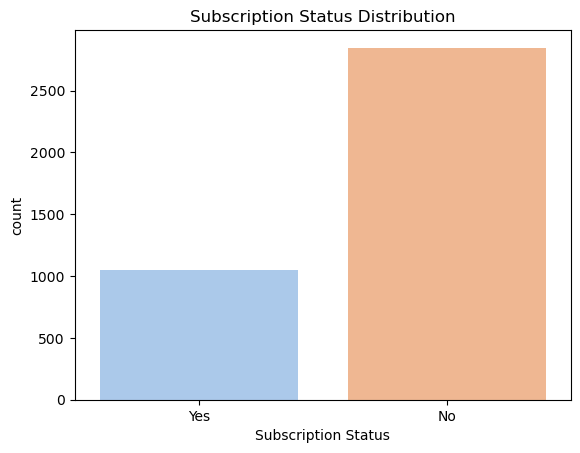

In [3]:
# Step 2 continued: Exploratory Data Analysis

import seaborn as sns
import matplotlib.pyplot as plt

# Class distribution of subscription status

sns.countplot(data=df, x="Subscription Status", hue="Subscription Status", palette="pastel", legend=False)
plt.title("Subscription Status Distribution")
plt.show()

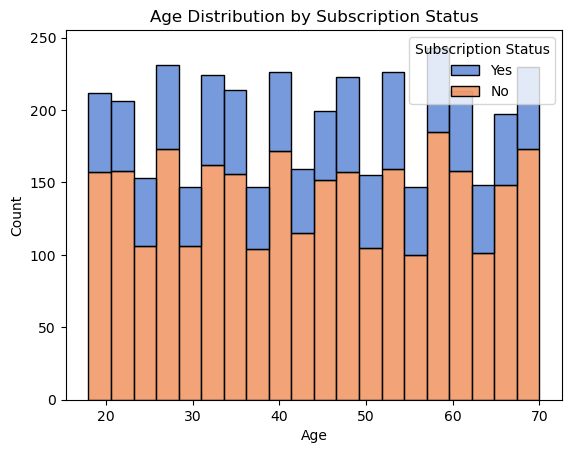

In [4]:
# Age distribution by subscription status

sns.histplot(data=df, x="Age", hue="Subscription Status", multiple="stack", palette="muted", bins=20)
plt.title("Age Distribution by Subscription Status")
plt.show()

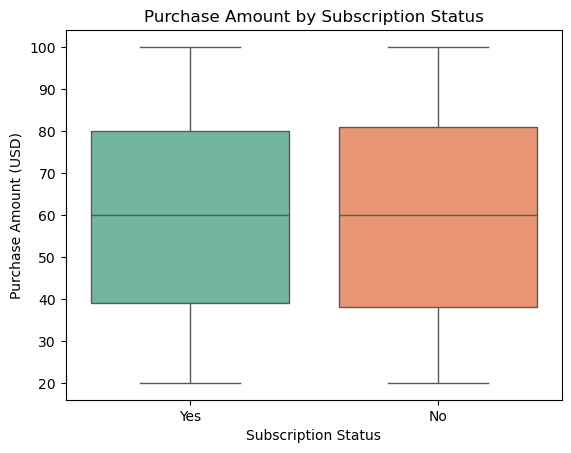

In [5]:
# Boxplot of purchase amount

sns.boxplot(data=df, x="Subscription Status", y="Purchase Amount (USD)", hue="Subscription Status", palette="Set2", legend=False)
plt.title("Purchase Amount by Subscription Status")
plt.show()

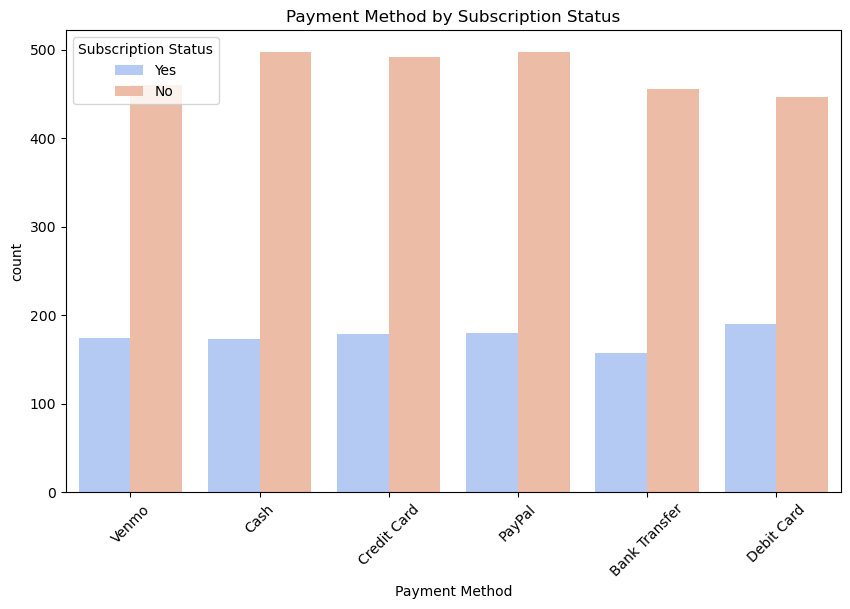

In [6]:
# Payment method vs. Subscription Status

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Payment Method", hue="Subscription Status", palette="coolwarm")
plt.title("Payment Method by Subscription Status")
plt.xticks(rotation=45)
plt.show()

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.93      0.80      0.86       558
           1       0.63      0.86      0.73       222

    accuracy                           0.82       780
   macro avg       0.78      0.83      0.79       780
weighted avg       0.85      0.82      0.82       780



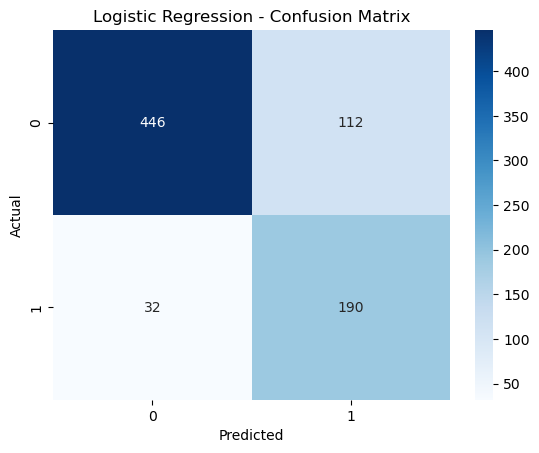

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.95      0.78      0.85       558
           1       0.62      0.90      0.73       222

    accuracy                           0.81       780
   macro avg       0.78      0.84      0.79       780
weighted avg       0.86      0.81      0.82       780



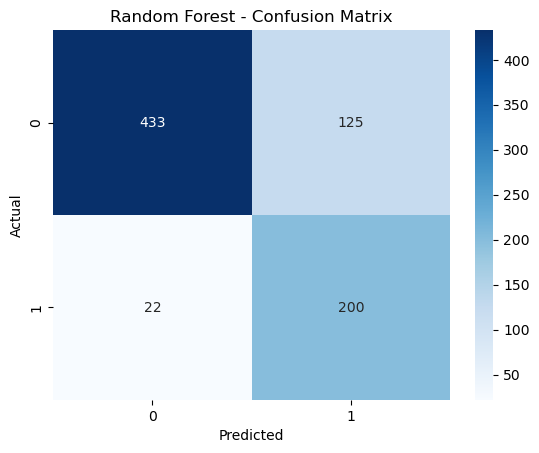

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.89      0.84      0.86       558
           1       0.64      0.75      0.69       222

    accuracy                           0.81       780
   macro avg       0.77      0.79      0.78       780
weighted avg       0.82      0.81      0.81       780



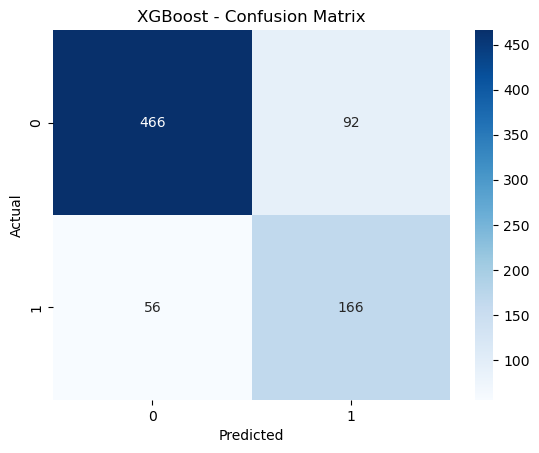

In [37]:
# Step 3: Model Selection and Implementation

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Drop irrelevant columns
df_model = df.drop(columns=["Customer ID", "Item Purchased"])

# 2. Define features and target
X = df_model.drop("Subscription Status", axis=1)
y = df_model["Subscription Status"].map({'Yes': 1, 'No': 0})  # Convert to binary

# 3. Identify column types
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# 4. Preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

# 5. Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Train and evaluate models
for name, model in models.items():
    print(f"--- {name} ---")
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [39]:
# Step 4: Model Evaluation and Comparison

# Cross-Validation Accuracy

from sklearn.model_selection import cross_val_score

cv_scores = {}
for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", model)
    ])
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
    cv_scores[name] = {
        "CV Mean Accuracy": scores.mean(),
        "CV Std Dev": scores.std()
    }

cv_scores_df = pd.DataFrame(cv_scores).T.reset_index().rename(columns={"index": "Model"})
cv_scores_df

,Model,CV Mean Accuracy,CV Std Dev
0,Logistic Regression,0.782308,0.256424
1,Random Forest,0.794359,0.262796
2,XGBoost,0.768462,0.247089


In [43]:
# Learning Curves (visualize bias vs. variance)

from sklearn.model_selection import cross_val_score, StratifiedKFold
import pandas as pd
from sklearn.pipeline import Pipeline

# Use StratifiedKFold to ensure each fold has both classes
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary of models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

# Evaluate cross-validation accuracy for each model
cv_scores = {}
for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessing", preprocessor),  # Assuming preprocessor is already defined
        ("classifier", model)
    ])
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
    cv_scores[name] = {
        "CV Mean Accuracy": scores.mean(),
        "CV Std Dev": scores.std()
    }

# Convert to DataFrame and show results
cv_scores_df = pd.DataFrame(cv_scores).T.reset_index().rename(columns={"index": "Model"})
cv_scores_df

,Model,CV Mean Accuracy,CV Std Dev
0,Logistic Regression,0.824615,0.009400
1,Random Forest,0.832051,0.012430
2,XGBoost,0.820769,0.005217


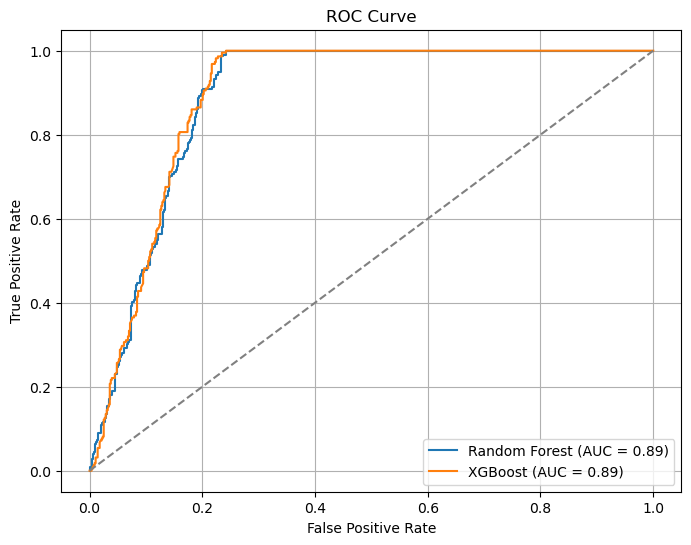

In [47]:
# Extended Evaluation: ROC Curves and Feature Importance

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilities
y_proba_rf = rf_grid.best_estimator_.predict_proba(X_test)[:, 1]
y_proba_xgb = xgb_grid.best_estimator_.predict_proba(X_test)[:, 1]

# ROC and AUC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

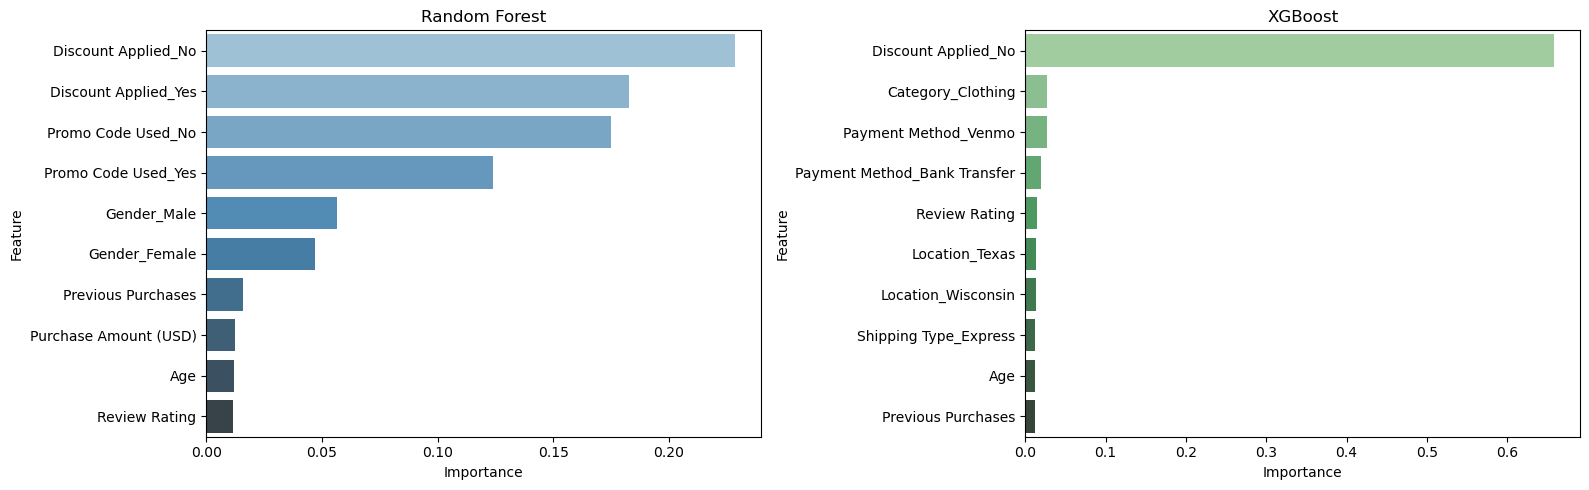

In [51]:
# Feature Importance Charts

# Get feature names
ohe = rf_grid.best_estimator_.named_steps['preprocessing'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out(categorical_cols)
all_features = numeric_cols + list(cat_features)

# Random Forest
rf_imp = rf_grid.best_estimator_.named_steps['classifier'].feature_importances_
rf_df = pd.DataFrame({'Feature': all_features, 'Importance': rf_imp}).sort_values(by="Importance", ascending=False).head(10)

# XGBoost
xgb_imp = xgb_grid.best_estimator_.named_steps['classifier'].feature_importances_
xgb_df = pd.DataFrame({'Feature': all_features, 'Importance': xgb_imp}).sort_values(by="Importance", ascending=False).head(10)

# Plot
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=rf_df, x="Importance", y="Feature", hue="Feature", legend=False, ax=axes[0], palette="Blues_d")
axes[0].set_title("Random Forest")

sns.barplot(data=xgb_df, x="Importance", y="Feature", hue="Feature", legend=False, ax=axes[1], palette="Greens_d")
axes[1].set_title("XGBoost")

plt.tight_layout()
plt.show()

In [45]:
# Step 5: Model Optimization

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd

# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest parameter grid
rf_params = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [5, 10],
    'classifier__min_samples_split': [2, 5]
}

# XGBoost parameter grid
xgb_params = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [3, 6],
    'classifier__learning_rate': [0.05, 0.1]
}

# Pipelines
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),  # Make sure preprocessor is defined
    ("classifier", RandomForestClassifier(random_state=42))
])

xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", XGBClassifier(eval_metric='logloss', random_state=42))
])

# Grid searches
rf_grid = GridSearchCV(rf_pipeline, rf_params, cv=cv, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)

xgb_grid = GridSearchCV(xgb_pipeline, xgb_params, cv=cv, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

# Display results
print("Random Forest Best Parameters:", rf_grid.best_params_)
print("Random Forest Best CV Accuracy:", rf_grid.best_score_)

print("\nXGBoost Best Parameters:", xgb_grid.best_params_)
print("XGBoost Best CV Accuracy:", xgb_grid.best_score_)

Random Forest Best Parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
Random Forest Best CV Accuracy: 0.8435897435897435

XGBoost Best Parameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
XGBoost Best CV Accuracy: 0.839423076923077
